In [2]:
import os
print(os.path.expanduser("~"))

C:\Users\preet


In [6]:
import os
os.chdir(r'C:\Users\preet\OneDrive\Desktop\Churn Analysis')
print(os.getcwd())

C:\Users\preet\OneDrive\Desktop\Churn Analysis


In [7]:
print(os.listdir())

['Telco_Churn.csv']


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imoorted successfully")

All libraries imoorted successfully


In [12]:
df = pd.read_csv('Telco_Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
# Check unique values in TotalCharges to find the issue
print(df['TotalCharges'].unique()[:20])

['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']


In [15]:
# Replace empty spaces with NaN and convert to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN values appeared
print(df['TotalCharges'].isnull().sum())

11


In [16]:
# Drop the 11 rows with missing TotalCharges
df = df.dropna(subset=['TotalCharges'])

# Confirm the fix
print(df.shape)
print(df['TotalCharges'].dtype)

(7032, 21)
float64


In [17]:
# Convert Churn from Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Check churn rate
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].mean()*100:.2f}%")

Churn
0    5163
1    1869
Name: count, dtype: int64

Churn Rate: 26.58%


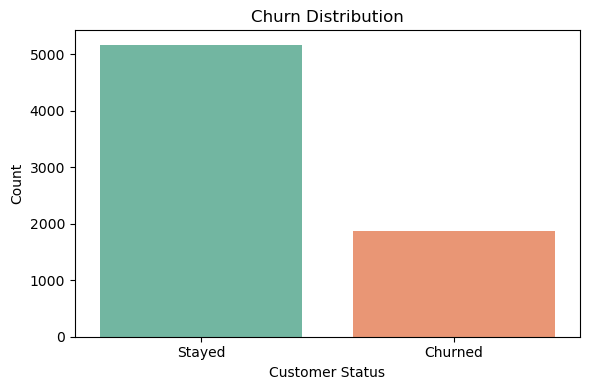

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, hue='Churn', palette='Set2', legend=False)
plt.title('Churn Distribution')
plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.xlabel('Customer Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

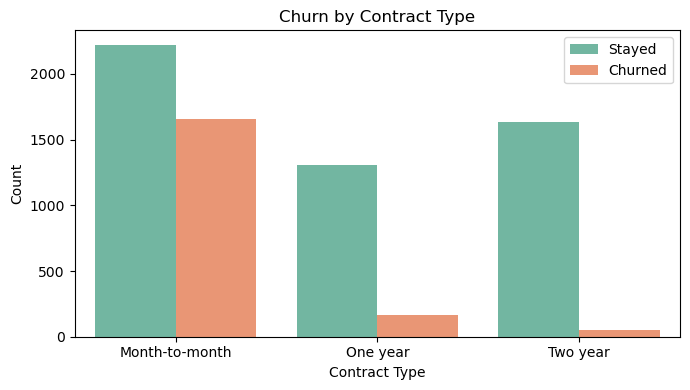

In [20]:
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', data=df, hue='Churn', palette='Set2')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.legend(['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

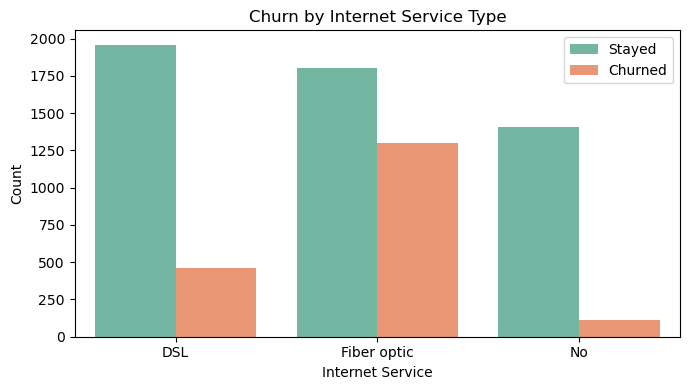

In [21]:
plt.figure(figsize=(7,4))
sns.countplot(x='InternetService', data=df, hue='Churn', palette='Set2')
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.legend(['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

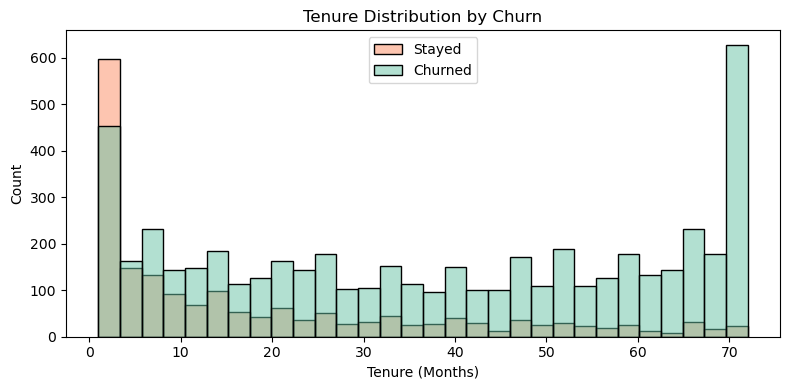

In [22]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='Set2')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.legend(['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

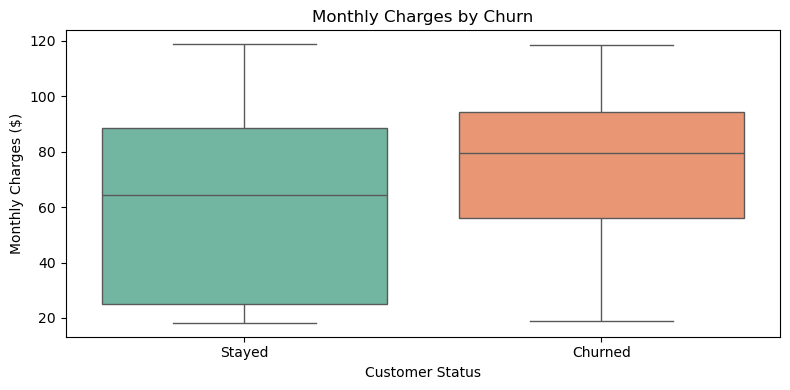

In [24]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Churn', data=df, y='MonthlyCharges', hue='Churn', palette='Set2', legend=False)
plt.title('Monthly Charges by Churn')
plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.xlabel('Customer Status')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

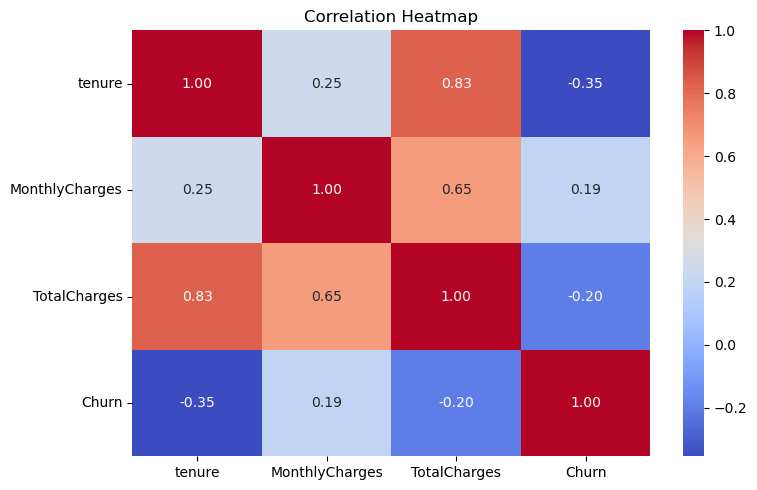

In [25]:
plt.figure(figsize=(8,5))
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [26]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\preet\OneDrive\Desktop\Churn Analysis
['Churn_Analysis_Queries.sql', 'Telco_Churn.csv']


In [28]:
import glob
files = glob.glob(r'C:\Users\preet\**\*.ipynb', recursive=True)
for f in files:
    print(f)

C:\Users\preet\apnaclg.ipynb
C:\Users\preet\chatgpt.ipynb
C:\Users\preet\Class 1.ipynb
C:\Users\preet\Class 2.ipynb
C:\Users\preet\Class 3.ipynb
C:\Users\preet\Class 4.ipynb
C:\Users\preet\Class 5.ipynb
C:\Users\preet\Class 6.ipynb
C:\Users\preet\Class 7.ipynb
C:\Users\preet\Class 8.ipynb
C:\Users\preet\Class 9.ipynb
C:\Users\preet\Copilot-P.ipynb
C:\Users\preet\Copilot.ipynb
C:\Users\preet\Customer_Shopping_Behavior_Analysis.ipynb
C:\Users\preet\insurance project.ipynb
C:\Users\preet\Loops.ipynb
C:\Users\preet\Matplotlib.ipynb
C:\Users\preet\Outliers Code.ipynb
C:\Users\preet\Pandas.ipynb
C:\Users\preet\Project.ipynb
C:\Users\preet\py from youtube.ipynb
C:\Users\preet\pythyt.ipynb
C:\Users\preet\Telco_Churn_Analysis.ipynb
C:\Users\preet\Untitled.ipynb
C:\Users\preet\Untitled1.ipynb
C:\Users\preet\Untitled10.ipynb
C:\Users\preet\Untitled2.ipynb
C:\Users\preet\Untitled3.ipynb
C:\Users\preet\Untitled4.ipynb
C:\Users\preet\Untitled5.ipynb
C:\Users\preet\Untitled6.ipynb
C:\Users\preet\Unti